C:\Users\Gaurang\AppData\Local\Temp\ipykernel_8924\2766550498.py:22: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])



Params: 64, 0.001 , 30, 32
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
Violation rate: 0.0017937219730941704

Params: 64, 0.001 , 30, 64
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
Violation rate: 0.0008968609865470852

Params: 64, 0.001 , 50, 32
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step
Violation rate: 0.0068759342301943195

Params: 64, 0.001 , 50, 64
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step
Violation rate: 0.0029895366218236174

Params: 64, 0.0005 , 30, 32
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step
Violation rate: 0.0242152466367713

Params: 64, 0.0005 , 30, 64
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step
Violation rate: 0.021225710014947684

Params: 64, 0.0005 , 50, 32
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step
Violation rate: 0.001195814648729447

Params: 64, 0.0005 , 50, 64
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step
Violation rate: 0.0029895366218236174

Params: 128, 0.001 , 30, 32
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step
Violation rate: 0.007174887892376682

Params: 128, 0.001 , 30, 64
21/21 ━━━━━━━━

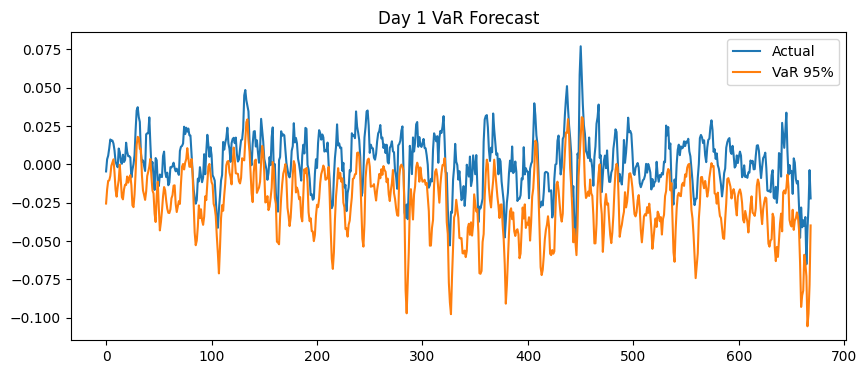

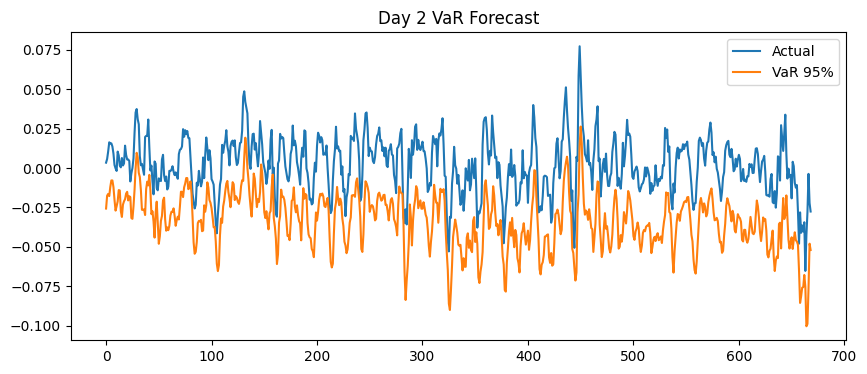

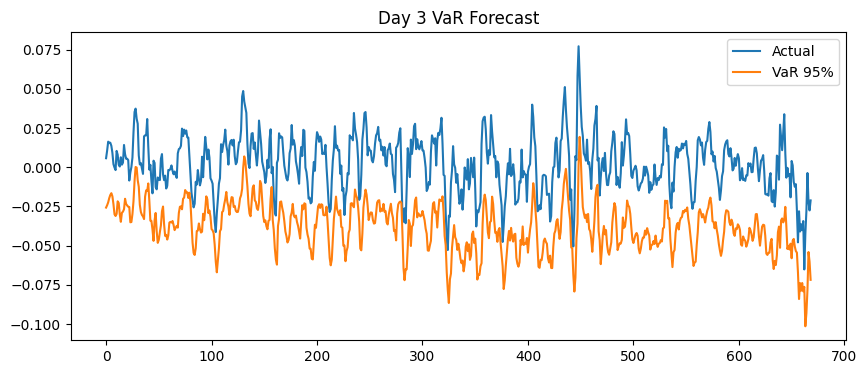

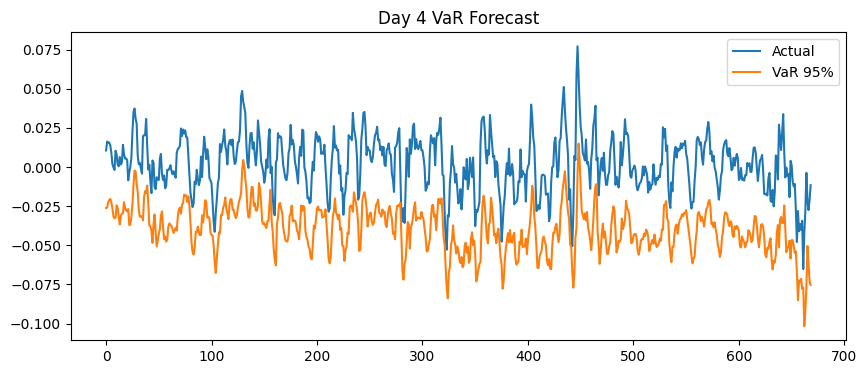

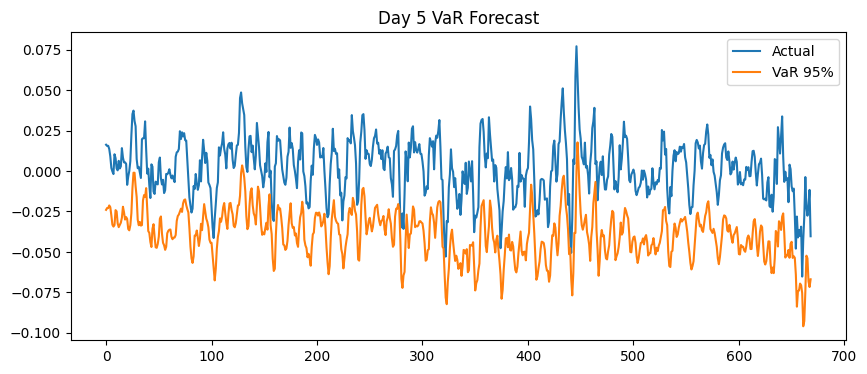

: 

In [ ]:
# =========================
# IMPORTS
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import zscore

import tensorflow as tf
from tensorflow.keras.layers import Input, GRU, Dense, Attention, Concatenate, TimeDistributed, Dot, Activation
from tensorflow.keras.models import Model

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("D:\\COLLEGE\\DAIICT\\Semester-2\\Applied Forecasting\\re_implemented_project\\data\\nifty50_with_sector_returns_yfinance1.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').set_index('date')

df = df[~df.index.duplicated()]
df = df.ffill().bfill()
df = df[(np.abs(zscore(df)) < 3).all(axis=1)]

# =========================
# FEATURE ENGINEERING
# =========================
df['return'] = df['close'].pct_change(5)
df = df.dropna()

for lag in range(1, 6):
    df[f'return_lag_{lag}'] = df['return'].shift(lag)

df['rolling_mean_5'] = df['return'].rolling(5).mean()
df['rolling_std_5'] = df['return'].rolling(5).std()

df['momentum'] = df['close'] - df['close'].shift(5)

delta = df['close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = -delta.clip(upper=0).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain/loss))

df['EMA_10'] = df['close'].ewm(span=10).mean()
df['volatility'] = df['return'].rolling(10).std()

df['bank_trend'] = df['nifty_bank_ret'].rolling(5).mean()
df['it_trend'] = df['nifty_it_ret'].rolling(5).mean()

df = df.dropna()

# =========================
# DATA PREP
# =========================
features = df.columns.tolist()
features.remove('return')

X = df[features]
y = df['return']

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))

def create_dataset(X, y, n_steps=20, horizon=5):
    Xs, ys = [], []
    for i in range(len(X) - n_steps - horizon):
        Xs.append(X[i:i+n_steps])
        ys.append(y[i+n_steps:i+n_steps+horizon])
    return np.array(Xs), np.array(ys)

n_steps = 20
horizon = 5

X_seq, y_seq = create_dataset(X_scaled, y_scaled, n_steps, horizon)

split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

y_train = y_train.reshape(-1, horizon, 1)
y_test = y_test.reshape(-1, horizon, 1)

# =========================
# TEACHER FORCING
# =========================
def create_decoder_input(y):
    decoder_input = np.zeros_like(y)
    decoder_input[:, 1:, :] = y[:, :-1, :]
    return decoder_input

decoder_input_train = create_decoder_input(y_train)
decoder_input_test = create_decoder_input(y_test)

# =========================
# QUANTILE LOSS
# =========================
def quantile_loss(q):
    def loss(y_true, y_pred):
        e = y_true - y_pred
        return tf.reduce_mean(tf.maximum(q*e, (q-1)*e))
    return loss

# =========================
# MODEL BUILDERS
# =========================

def build_gru(n_steps, n_features, horizon, units, lr, q):
    inputs = Input(shape=(n_steps, n_features))
    x = GRU(units, return_sequences=True)(inputs)
    x = Attention()([x, x])
    x = Concatenate()([x, x])
    x = GRU(units)(x)
    outputs = Dense(horizon)(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss=quantile_loss(q))
    return model


def build_seq2seq(n_steps, n_features, horizon, units, lr, q):
    enc_in = Input(shape=(n_steps, n_features))
    _, state = GRU(units, return_state=True)(enc_in)

    dec_in = Input(shape=(horizon,1))
    dec = GRU(units, return_sequences=True)(dec_in, initial_state=state)

    out = TimeDistributed(Dense(1))(dec)

    model = Model([enc_in, dec_in], out)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss=quantile_loss(q))
    return model


def build_seq2seq_attn(n_steps, n_features, horizon, units, lr, q):
    enc_in = Input(shape=(n_steps, n_features))
    enc_out, state = GRU(units, return_sequences=True, return_state=True)(enc_in)

    dec_in = Input(shape=(horizon,1))
    dec_out = GRU(units, return_sequences=True)(dec_in, initial_state=state)

    score = Dot(axes=[2,2])([dec_out, enc_out])
    weights = Activation('softmax')(score)
    context = Dot(axes=[2,1])([weights, enc_out])

    comb = Concatenate()([context, dec_out])
    out = TimeDistributed(Dense(1))(comb)

    model = Model([enc_in, dec_in], out)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss=quantile_loss(q))
    return model

# =========================
# GRID SEARCH
# =========================
param_grid = {
    'units':[64,128],
    'lr':[0.001,0.0005],
    'epochs':[30, 50],
    'batch':[32,64]
}

best_score = float('inf')

for units, lr, epochs, batch in itertools.product(*param_grid.values()):
    
    print(f"\nParams: {units}, {lr} , {epochs}, {batch}")

    # Train 95% model (q=0.05)
    model = build_seq2seq_attn(n_steps, X_train.shape[2], horizon, units, lr, q=0.05)

    model.fit([X_train, decoder_input_train], y_train,
              epochs=epochs, batch_size=batch, verbose=0)

    pred = model.predict([X_test, decoder_input_test])

    # inverse
    y_true = scaler_y.inverse_transform(y_test.reshape(-1,1)).reshape(-1,horizon)
    y_pred = scaler_y.inverse_transform(pred.reshape(-1,1)).reshape(-1,horizon)

    # VaR violation
    violation = (y_true < y_pred).mean()

    print("Violation rate:", violation)

    if violation < best_score:
        best_score = violation
        best_model = model

# =========================
# FINAL PREDICTIONS
# =========================
model_95 = build_seq2seq_attn(n_steps, X_train.shape[2], horizon, 128, 0.0005, q=0.05)

model_95.fit([X_train, decoder_input_train], y_train, epochs=30, batch_size=32, verbose=0)

pred_95 = model_95.predict([X_test, decoder_input_test])


y_true = scaler_y.inverse_transform(y_test.reshape(-1,1)).reshape(-1,horizon)
VaR_95 = scaler_y.inverse_transform(pred_95.reshape(-1,1)).reshape(-1,horizon)


# =========================
# BACKTEST
# =========================
def var_backtest(y, var, alpha):
    violations = (y < var).astype(int)
    rate = violations.mean()
    print(f"VaR {int((1-alpha)*100)}% violation rate:", rate)
    return violations

v95 = var_backtest(y_true, VaR_95, 0.05)


# =========================
# VISUALIZATION
# =========================
for i in range(horizon):
    plt.figure(figsize=(10,4))
    plt.plot(y_true[:,i], label="Actual")
    plt.plot(VaR_95[:,i], label="VaR 95%")
    plt.title(f"Day {i+1} VaR Forecast")
    plt.legend()
    plt.show()

C:\Users\Gaurang\AppData\Local\Temp\ipykernel_8872\1997086938.py:20: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])


21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step
PICP (Expected ~0.95): 0.9668161434977578
MPIW: 0.049320273
------------------------------


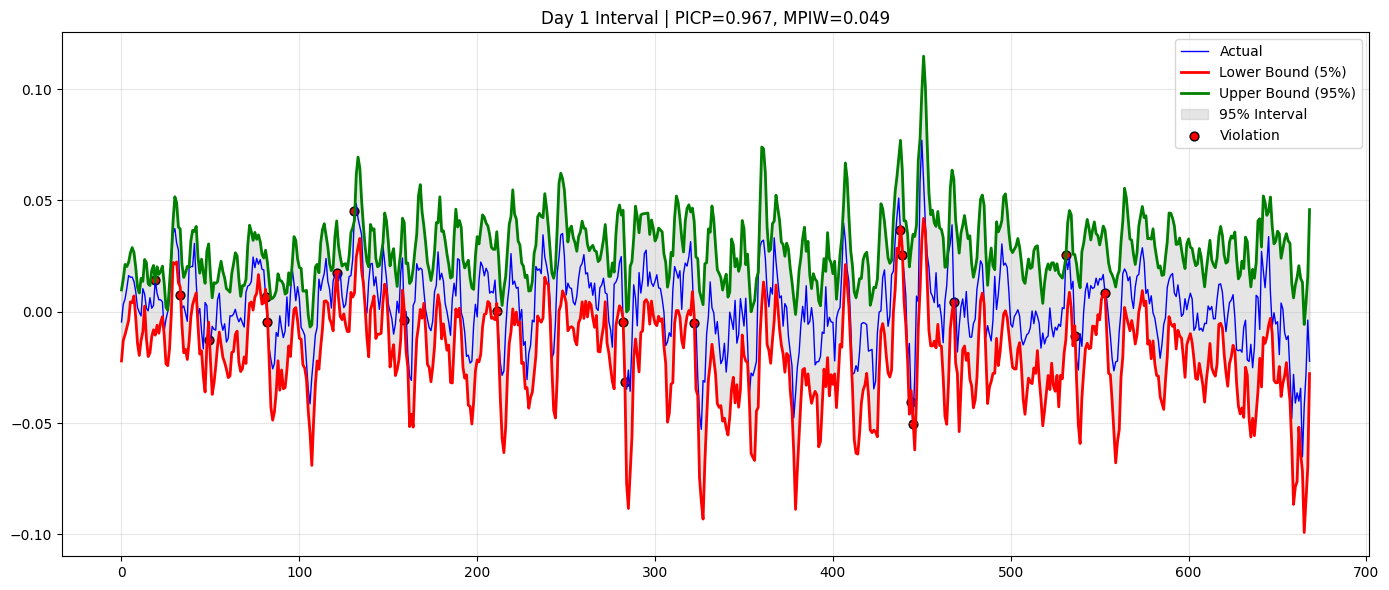

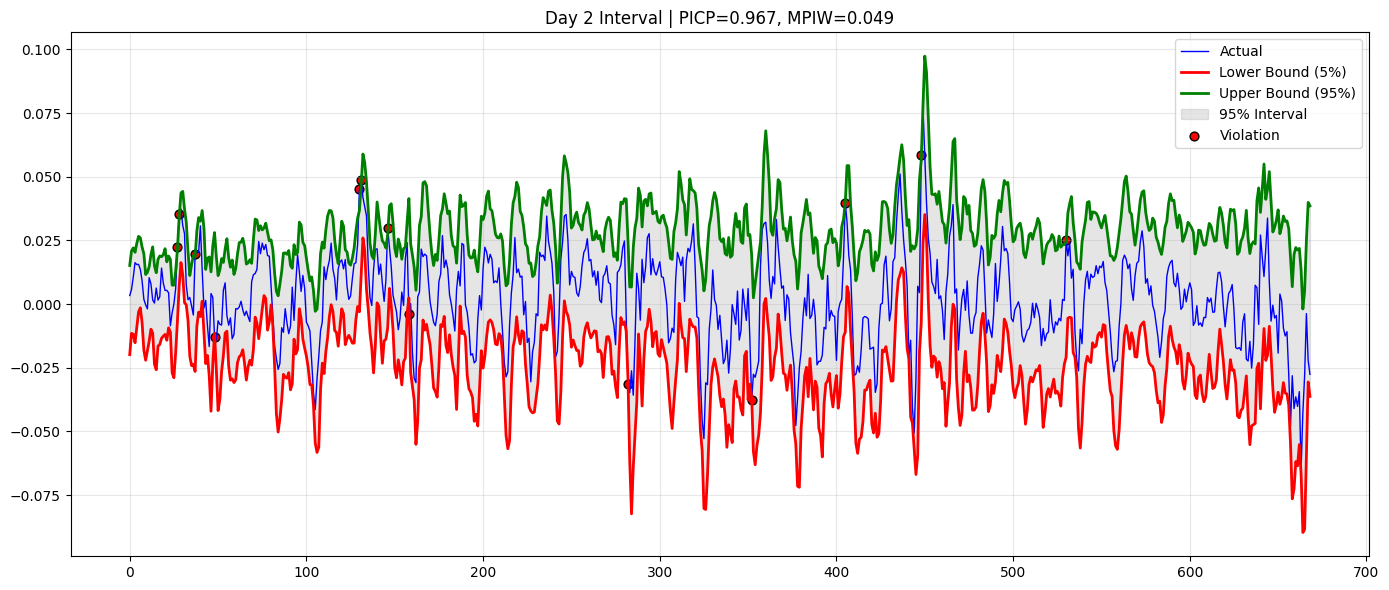

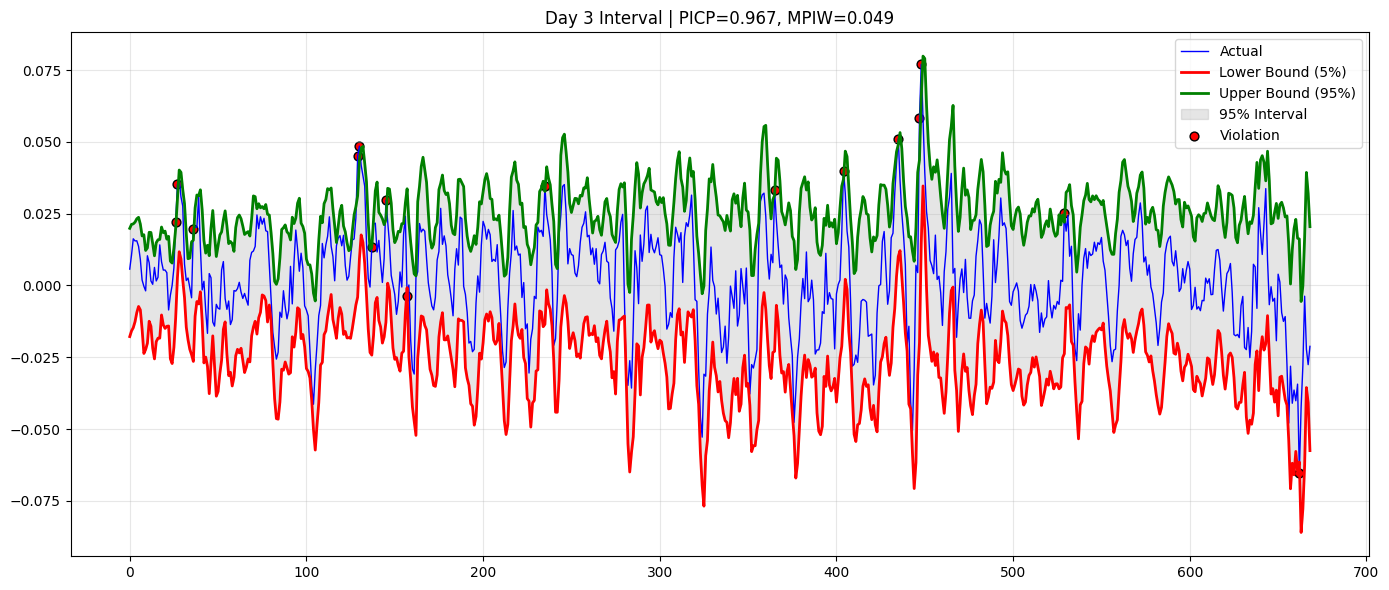

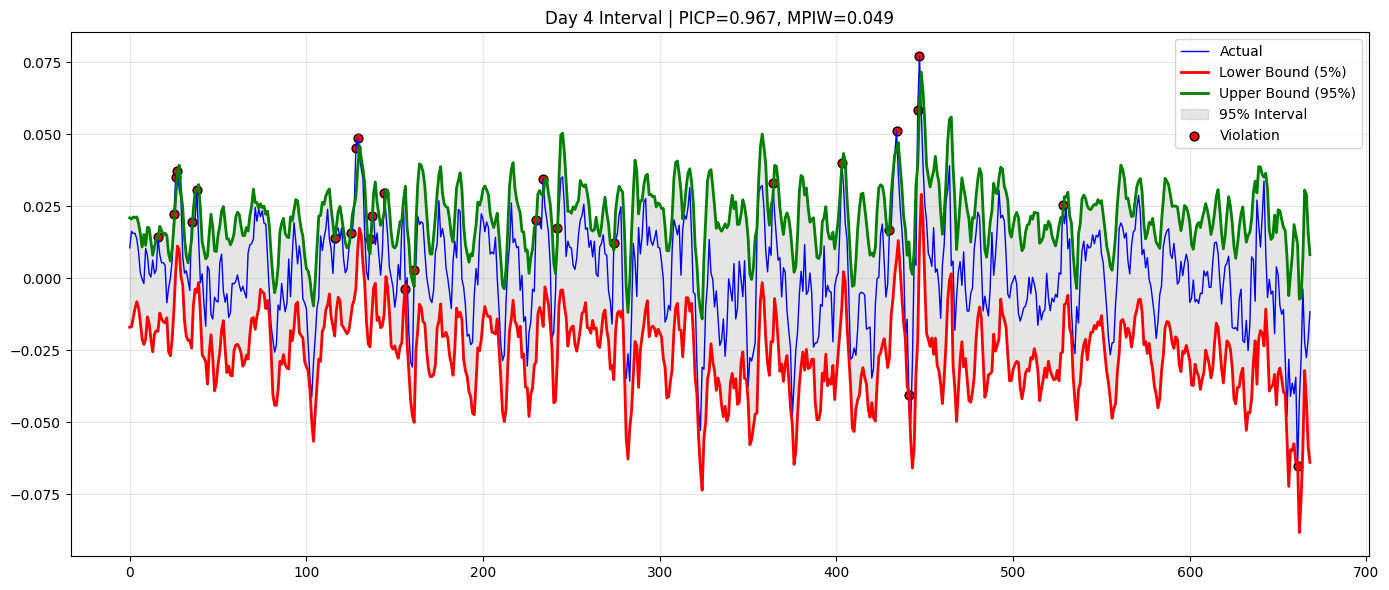

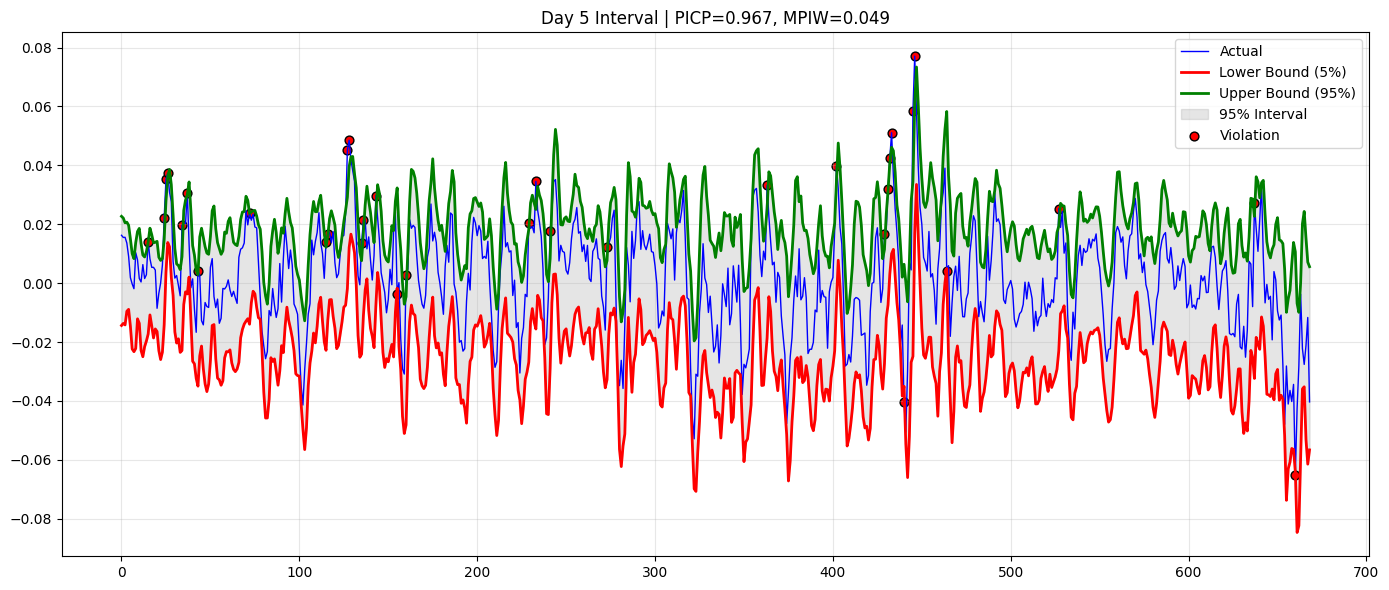

In [10]:
# =========================
# IMPORTS
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from scipy.stats import zscore

import tensorflow as tf
from tensorflow.keras.layers import Input, GRU, Dense, Concatenate, TimeDistributed, Dot, Activation
from tensorflow.keras.models import Model

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("D:\\COLLEGE\\DAIICT\\Semester-2\\Applied Forecasting\\re_implemented_project\\data\\nifty50_with_sector_returns_yfinance1.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').set_index('date')

df = df[~df.index.duplicated()]
df = df.ffill().bfill()
df = df[(np.abs(zscore(df)) < 3).all(axis=1)]

# =========================
# FEATURE ENGINEERING
# =========================
df['return'] = df['close'].pct_change(5)
df = df.dropna()

for lag in range(1, 6):
    df[f'return_lag_{lag}'] = df['return'].shift(lag)

df['rolling_mean_5'] = df['return'].rolling(5).mean()
df['rolling_std_5'] = df['return'].rolling(5).std()

df['momentum'] = df['close'] - df['close'].shift(5)

delta = df['close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = -delta.clip(upper=0).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain/loss))

df['EMA_10'] = df['close'].ewm(span=10).mean()
df['volatility'] = df['return'].rolling(10).std()

df['bank_trend'] = df['nifty_bank_ret'].rolling(5).mean()
df['it_trend'] = df['nifty_it_ret'].rolling(5).mean()

df = df.dropna()

# =========================
# DATA PREP
# =========================
features = df.columns.tolist()
features.remove('return')

X = df[features]
y = df['return']

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))

def create_dataset(X, y, n_steps=20, horizon=5):
    Xs, ys = [], []
    for i in range(len(X) - n_steps - horizon):
        Xs.append(X[i:i+n_steps])
        ys.append(y[i+n_steps:i+n_steps+horizon])
    return np.array(Xs), np.array(ys)

n_steps = 20
horizon = 5

X_seq, y_seq = create_dataset(X_scaled, y_scaled, n_steps, horizon)

split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

y_train = y_train.reshape(-1, horizon, 1)
y_test = y_test.reshape(-1, horizon, 1)

# =========================
# TEACHER FORCING
# =========================
def create_decoder_input(y):
    decoder_input = np.zeros_like(y)
    decoder_input[:, 1:, :] = y[:, :-1, :]
    return decoder_input

decoder_input_train = create_decoder_input(y_train)
decoder_input_test = create_decoder_input(y_test)

# =========================
# QUANTILE LOSS
# =========================
def quantile_loss(q):
    def loss(y_true, y_pred):
        e = y_true - y_pred
        return tf.reduce_mean(tf.maximum(q*e, (q-1)*e))
    return loss

# =========================
# MODEL
# =========================
def build_seq2seq_attn(n_steps, n_features, horizon, units, lr, q):
    enc_in = Input(shape=(n_steps, n_features))
    enc_out, state = GRU(units, return_sequences=True, return_state=True)(enc_in)

    dec_in = Input(shape=(horizon,1))
    dec_out = GRU(units, return_sequences=True)(dec_in, initial_state=state)

    score = Dot(axes=[2,2])([dec_out, enc_out])
    weights = Activation('softmax')(score)
    context = Dot(axes=[2,1])([weights, enc_out])

    comb = Concatenate()([context, dec_out])
    out = TimeDistributed(Dense(1))(comb)

    model = Model([enc_in, dec_in], out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss=quantile_loss(q))
    return model

# =========================
# TRAIN MODELS
# =========================
model_low = build_seq2seq_attn(n_steps, X_train.shape[2], horizon, 128, 0.0005, q=0.05)
model_high = build_seq2seq_attn(n_steps, X_train.shape[2], horizon, 128, 0.0005, q=0.95)

model_low.fit([X_train, decoder_input_train], y_train, epochs=30, batch_size=32, verbose=0)
model_high.fit([X_train, decoder_input_train], y_train, epochs=30, batch_size=32, verbose=0)

# =========================
# PREDICTIONS
# =========================
pred_low = model_low.predict([X_test, decoder_input_test])
pred_high = model_high.predict([X_test, decoder_input_test])

# =========================
# INVERSE SCALING
# =========================
y_true = scaler_y.inverse_transform(y_test.reshape(-1,1)).reshape(-1,horizon)
VaR_low = scaler_y.inverse_transform(pred_low.reshape(-1,1)).reshape(-1,horizon)
VaR_high = scaler_y.inverse_transform(pred_high.reshape(-1,1)).reshape(-1,horizon)

# =========================
# PICP & MPIW
# =========================
def picp(y, low, high):
    return np.mean((y >= low) & (y <= high))

def mpiw(low, high):
    return np.mean(high - low)

PICP = picp(y_true, VaR_low, VaR_high)
MPIW = mpiw(VaR_low, VaR_high)

print("PICP (Expected ~0.95):", PICP)
print("MPIW:", MPIW)
print("-"*30)

# =========================
# VISUALIZATION
# =========================
for i in range(horizon):
    plt.figure(figsize=(14,6))

    # Actual
    plt.plot(y_true[:, i], label="Actual", color='blue', linewidth=1)

    # Lower bound
    plt.plot(VaR_low[:, i], label="Lower Bound (5%)", color='red', linewidth=2)

    # Upper bound
    plt.plot(VaR_high[:, i], label="Upper Bound (95%)", color='green', linewidth=2)

    # Interval shading
    plt.fill_between(
        range(len(y_true)),
        VaR_low[:, i],
        VaR_high[:, i],
        color='gray',
        alpha=0.2,
        label="95% Interval"
    )

    # Violations (both sides)
    violations = (y_true[:, i] < VaR_low[:, i]) | (y_true[:, i] > VaR_high[:, i])

    plt.scatter(
        np.where(violations)[0],
        y_true[violations, i],
        color='red',
        s=40,
        edgecolor='black',
        label="Violation"
    )

    plt.grid(alpha=0.3)

    plt.title(f"Day {i+1} Interval | PICP={PICP:.3f}, MPIW={MPIW:.3f}")
    plt.legend()
    plt.tight_layout()
    plt.show()